In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [2]:
import neuroboros as nb
import numpy as np
from scipy.stats import ttest_rel

In [3]:
results = nb.load('summary/isc_dallas.pkl')

In [4]:
list(results)

[('young', 'young'),
 ('mid', 'young'),
 ('old', 'young'),
 ('young', 'mid'),
 ('mid', 'mid'),
 ('old', 'mid'),
 ('young', 'old'),
 ('mid', 'old'),
 ('old', 'old')]

In [5]:
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        print(results[test_grp, tpl_grp].shape)

(10, 182, 19341)
(10, 182, 19341)
(10, 92, 19341)
(10, 92, 19341)


In [7]:
rocket = sns.color_palette("rocket", 5)
mako = sns.color_palette("mako", 5)

colors = [mpl.colors.to_rgb(mpl.colors.cnames[_])
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]

config = [
    [0, zz['old', 'old'], rocket[2]],
    [1, zz['old', 'young'], rocket[4]],
    [2.5, zz['young', 'young'], mako[2]],
    [3.5, zz['young', 'old'], mako[4]],
]

In [8]:
d1 = zz['old', 'old'] - zz['old', 'young']
d2 = zz['young', 'young'] - zz['young', 'old']

m1 = d1.mean()
se1 = d1.std(ddof=1) / np.sqrt(len(d1))
# b1 = bootstrap_mean(d1)
# yerr1 = np.abs(np.percentile(b1, [2.5, 97.5]) - m1)
m2 = d2.mean()
se2 = d2.std(ddof=1) / np.sqrt(len(d2))
# b2 = bootstrap_mean(d2)
# yerr2 = np.abs(np.percentile(b2, [2.5, 97.5]) - m2)

In [11]:
len(d1)

182

In [13]:
np.sum(d1 > 0)/len(d1)

0.5769230769230769

In [14]:
np.sum(d2 > 0) / len(d2)

0.9239130434782609

85

In [15]:
m1

0.0024633856730682767

In [16]:
se1

0.0005914695674226396

In [17]:
m2

0.0052526566084420915

In [18]:
se2

0.00039665034260779935

In [25]:
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
c1 = (colors[0] + colors[1]) * 0.5
c2 = (colors[2] + colors[3]) * 0.5

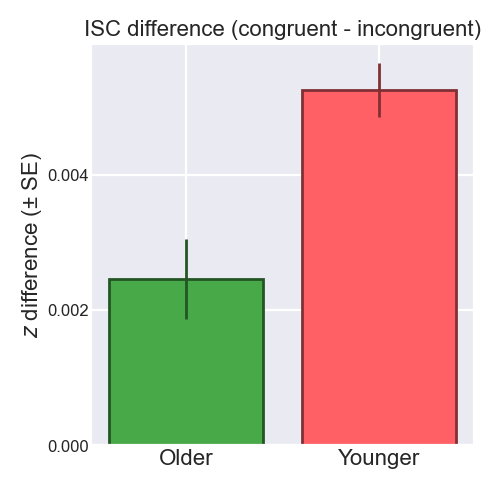

In [30]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5)
    ax.bar(1, m2, color=c2, ec=c2*0.5)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1, m2, yerr=se2, c=c2*0.5, **kwargs)
    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1], labels=['Older', 'Younger'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=1)
    ax.set_yticks(np.arange(3)*0.002)
    ax.set_title('ISC difference (congruent - incongruent)', size=8, pad=3)
    fig.subplots_adjust(left=0.16, top=0.92, bottom=0.06, right=0.98)
    plt.savefig('figures/isc_diff_dallas.png', dpi=300)
    plt.show()

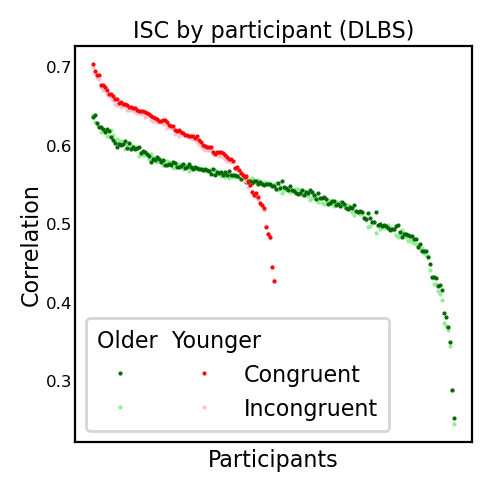

In [31]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
handles = []
for ii, (a, b) in enumerate([[zz['old', 'old'], zz['old', 'young']], [zz['young', 'young'], zz['young', 'old']]]):
    # with sns.axes_style('darkgrid'):
        # idx = np.argsort(a)[::-1]
        idx = np.argsort((a + b))[::-1]
        a, b = np.tanh(a[idx]), np.tanh(b[idx])
        x = np.arange(len(a))
        kwargs = dict(markersize=1)
        handles += ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)
        handles += ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
handles = [handles[_] for _ in [1, 0, 3, 2]]
ax.tick_params(size=0, pad=1, labelsize=6)
ax.set_ylabel('Correlation', size=8, labelpad=1)
ax.set_xticks([])
ax.set_xlabel('Participants', size=8, labelpad=2)
ax.set_title('ISC by participant (DLBS)', size=8, pad=3)
ax.legend(handles=handles, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
fig.subplots_adjust(left=0.13, top=0.92, bottom=0.07, right=0.98)
plt.savefig('figures/isc_dist_dallas.png', dpi=300)
plt.show()

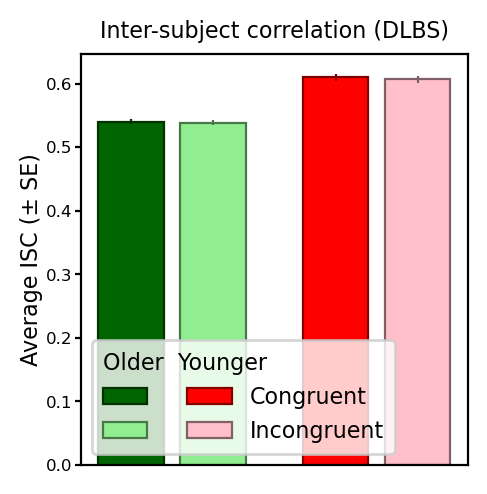

In [23]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)

bars = []
for ii, (x, z, c) in enumerate(config):
    c = colors[ii]
    ec = 0.5 * np.array(c)
    zm = z.mean()
    ze = z.std(ddof=1)/np.sqrt(len(z))
    m = np.tanh(zm)
    yerr = np.abs(np.tanh([zm-ze, zm+ze]) - m)
    b = ax.bar(x, m, color=c, ec=ec, lw=0.8)
    bars.append(b)
    ax.errorbar(x, m, yerr=yerr[:, None], color=ec, lw=0.8)
ax.set_xticks([])
ax.tick_params(size=2, pad=1, labelsize=6)
ax.set_ylabel('Average ISC (± SE)', size=8, labelpad=1)
ax.legend(handles=bars, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
ax.set_title('Inter-subject correlation (DLBS)', size=8)
fig.subplots_adjust(left=0.15, right=0.98, top=0.9, bottom=0.02)
plt.savefig('figures/isc_errorbar_dallas.png', dpi=300)
plt.show()

In [6]:
zz = {}
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        res = results[test_grp, tpl_grp]
        zz[test_grp, tpl_grp] = np.arctanh(res).mean(axis=(0, 2))

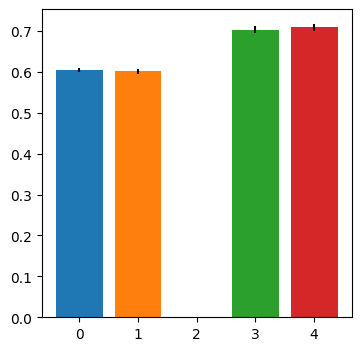

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for ii, test_grp in enumerate(['old', 'young']):
    for jj, tpl_grp in enumerate(['old', 'young']):
        z = zz[test_grp, tpl_grp]
        x = ii * 3 + jj
        ax.bar(x, z.mean())
        ax.errorbar(x, z.mean(), yerr=z.std(ddof=1)/np.sqrt(len(z)), color='k')
plt.show()

In [10]:
ttest_rel(zz['old', 'old'], zz['old', 'young'])

TtestResult(statistic=4.164856162934319, pvalue=4.816333690486751e-05, df=181)

In [11]:
ttest_rel(zz['young', 'young'], zz['young', 'old'])

TtestResult(statistic=13.242536421141638, pvalue=6.120571513130637e-23, df=91)

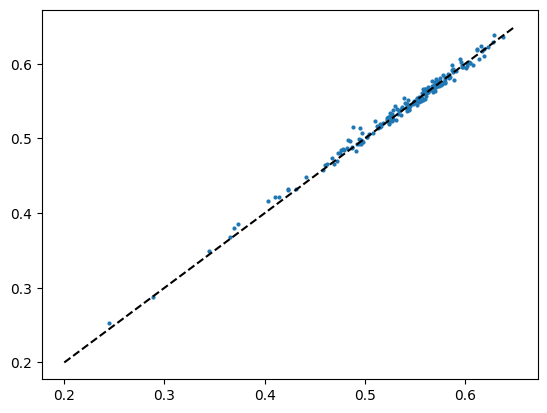

In [12]:
plt.scatter(np.tanh(zz['old', 'young']), np.tanh(zz['old', 'old']), s=4)
lim = [0.2, 0.65]
plt.plot(lim, lim, 'k--')
plt.show()

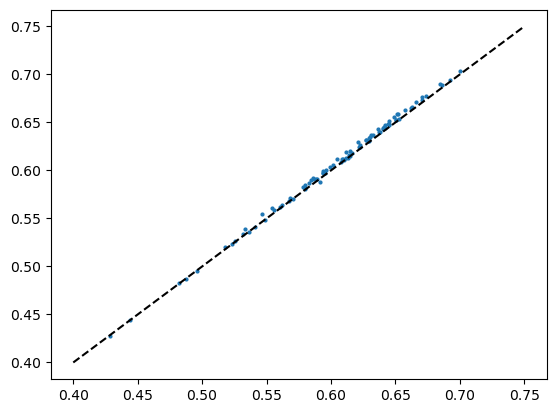

In [12]:
plt.scatter(np.tanh(zz['young', 'old']), np.tanh(zz['young', 'young']), s=4)
lim = [0.4, 0.75]
plt.plot(lim, lim, 'k--')
plt.show()